In [ ]:
!pip install GEOparse

In [ ]:
import GEOparse
import pandas as pd

In [ ]:
gse = GEOparse.get_GEO("GSE5281", destdir="./")

23-May-2026 18:15:42 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
23-May-2026 18:15:42 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE5nnn/GSE5281/soft/GSE5281_family.soft.gz to ./GSE5281_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE5nnn/GSE5281/soft/GSE5281_family.soft.gz to ./GSE5281_family.soft.gz
100%|██████████| 88.6M/88.6M [00:00<00:00, 101MB/s]
23-May-2026 18:15:43 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
23-May-2026 18:15:43 DEBUG downloader - Moving /tmp/tmpmw79i1lc to /content/GSE5281_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpmw79i1lc to /content/GSE5281_family.soft.gz
23-May-2026 18:15:43 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE5nnn/GSE5281/soft/GSE5281_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE5nnn/GSE5281/soft/GSE5281

In [ ]:
print(gse)

<SERIES: GSE5281 - 161 SAMPLES, 1 d(s)>


In [ ]:
list(gse.gsms.keys())[:10]

['GSM119615',
 'GSM119616',
 'GSM119617',
 'GSM119618',
 'GSM119619',
 'GSM119620',
 'GSM119621',
 'GSM119622',
 'GSM119623',
 'GSM119624']

In [ ]:
sample = gse.gsms[list(gse.gsms.keys())[0]]

print(sample.metadata)

{'title': ['EC control 1'], 'geo_accession': ['GSM119615'], 'status': ['Public on Jul 10 2006'], 'submission_date': ['Jul 10 2006'], 'last_update_date': ['Jun 26 2019'], 'type': ['RNA'], 'channel_count': ['1'], 'source_name_ch1': ['brain, Entorhinal Cortex'], 'organism_ch1': ['Homo sapiens'], 'taxid_ch1': ['9606'], 'characteristics_ch1': ['Sample Amount: 10 ug', 'Bio-Source Name: EC control 1', 'Organism: Human', 'Organ/Tissue Type: brain', 'Organ Region: Entorhinal Cortex', 'Cell Type: layer III neurons', 'Ethnicity: Caucasian', 'Developmental Stage: Adult', 'Disease State: normal', 'Sex: male', 'Genetic Variation: None', 'Age: 63 years'], 'molecule_ch1': ['total RNA'], 'description': ['arrayconsortium.tgen.org::biosample.433887', 'AD control'], 'platform_id': ['GPL570'], 'contact_name': ['Winnie,,Liang'], 'contact_email': ['wliang@tgen.org'], 'contact_institute': ['Translational Genomics'], 'contact_address': ['445 N. Fifth Street'], 'contact_city': ['Phoenix'], 'contact_state': ['AZ

In [ ]:
sample_info = []

for gsm_name, gsm in gse.gsms.items():

    title = gsm.metadata.get("title", ["NA"])[0]

    characteristics = gsm.metadata.get("characteristics_ch1", [])

    disease_state = "Unknown"

    for item in characteristics:
        if "Disease State" in item:
            disease_state = item.split(":")[-1].strip()

    brain_region = "Unknown"

    for item in characteristics:
        if "Organ Region" in item:
            brain_region = item.split(":")[-1].strip()

    sample_info.append([gsm_name, title, disease_state, brain_region])

sample_df = pd.DataFrame(
    sample_info,
    columns=["Sample_ID", "Title", "Disease_State", "Brain_Region"]
)

sample_df.head(10)

,Sample_ID,Title,Disease_State,Brain_Region
0,GSM119615,EC control 1,normal,Entorhinal Cortex
1,GSM119616,EC control 2,normal,Entorhinal Cortex
2,GSM119617,EC control 3,normal,Entorhinal Cortex
3,GSM119618,EC control 4,normal,Entorhinal Cortex
4,GSM119619,EC control 5,normal,Entorhinal Cortex
5,GSM119620,EC control 6,normal,Entorhinal Cortex
6,GSM119621,EC control 7,normal,Entorhinal Cortex
7,GSM119622,EC control 8,normal,Entorhinal Cortex
8,GSM119623,EC control 9,normal,Entorhinal Cortex
9,GSM119624,EC control 10,normal,Entorhinal Cortex


In [ ]:
sample_df[sample_df["Disease_State"] == "Unknown"].head(60)

,Sample_ID,Title,Disease_State,Brain_Region
38,GSM119653,PC control 1,Unknown,Unknown
39,GSM119654,PC control 2,Unknown,Unknown
40,GSM119655,PC control 3,Unknown,Unknown
41,GSM119656,PC control 4,Unknown,Unknown
42,GSM119657,PC control 5,Unknown,Unknown
43,GSM119658,PC control 6,Unknown,Unknown
44,GSM119659,PC control 7,Unknown,Unknown
45,GSM119660,PC control 8,Unknown,Unknown
46,GSM119661,PC control 9,Unknown,Unknown
47,GSM119662,PC control 10,Unknown,Unknown


In [ ]:
def classify_sample(title, disease_state):

    title_lower = title.lower()
    disease_lower = disease_state.lower()

    # Existing disease metadata
    if "ad" in disease_lower:
        return "AD"

    if "normal" in disease_lower or "control" in disease_lower:
        return "Control"

    # Infer from title
    if "control" in title_lower:
        return "Control"

    if "affected" in title_lower or "ad" in title_lower:
        return "AD"

    return "Unknown"


sample_df["Cleaned_Disease_State"] = sample_df.apply(
    lambda row: classify_sample(row["Title"], row["Disease_State"]),
    axis=1
)

sample_df.head(20)

,Sample_ID,Title,Disease_State,Brain_Region,Cleaned_Disease_State
0,GSM119615,EC control 1,normal,Entorhinal Cortex,Control
1,GSM119616,EC control 2,normal,Entorhinal Cortex,Control
2,GSM119617,EC control 3,normal,Entorhinal Cortex,Control
3,GSM119618,EC control 4,normal,Entorhinal Cortex,Control
4,GSM119619,EC control 5,normal,Entorhinal Cortex,Control
5,GSM119620,EC control 6,normal,Entorhinal Cortex,Control
6,GSM119621,EC control 7,normal,Entorhinal Cortex,Control
7,GSM119622,EC control 8,normal,Entorhinal Cortex,Control
8,GSM119623,EC control 9,normal,Entorhinal Cortex,Control
9,GSM119624,EC control 10,normal,Entorhinal Cortex,Control


In [ ]:
sample_df["Cleaned_Disease_State"].value_counts()

,count
Cleaned_Disease_State,
AD,87
Control,74


In [ ]:
expression_data = {}

for gsm_name, gsm in gse.gsms.items():

    # Get expression table
    table = gsm.table[["ID_REF", "VALUE"]]

    # Create series
    expression_data[gsm_name] = table.set_index("ID_REF")["VALUE"]

# Combine all samples into one dataframe
expression_df = pd.DataFrame(expression_data)

expression_df.head()

,GSM119615,GSM119616,GSM119617,GSM119618,GSM119619,GSM119620,GSM119621,GSM119622,GSM119623,GSM119624,...,GSM238945,GSM238946,GSM238947,GSM238948,GSM238949,GSM238951,GSM238952,GSM238953,GSM238955,GSM238963
ID_REF,,,,,,,,,,,,,,,,,,,,,
AFFX-BioB-5_at,276.48065,173.88646,340.41595,462.01385,969.22784,315.65262,795.8944,418.46713,256.37512,291.71990,...,972.155,2605.98,1875.17,1782.76,1814.72,543.331,1170.22,589.424,2318.74,2210.29
AFFX-BioB-M_at,391.85696,248.44994,395.96880,605.42900,1353.37960,499.42575,952.3778,457.69040,325.48820,377.04550,...,1736.170,4610.97,3108.58,3589.84,3345.61,884.611,1943.20,891.003,3872.99,3533.48
AFFX-BioB-3_at,269.12082,129.08673,256.59427,268.40040,846.79960,217.21541,606.7527,336.62122,187.43900,223.54672,...,970.950,3009.04,1872.00,2237.92,2081.44,549.718,1222.46,560.008,2434.82,2363.41
AFFX-BioC-5_at,852.27240,581.81170,1096.70630,1461.09670,2789.57810,1115.10230,2507.3018,1311.18760,927.73520,995.29266,...,2425.160,6232.20,4171.50,5293.12,4604.43,1805.260,4011.16,1691.090,5098.79,6520.74
AFFX-BioC-3_at,821.93243,849.97516,1438.47100,1698.32970,3443.69460,1456.83190,3133.8057,1812.01250,1187.36350,1282.10860,...,2543.770,6462.53,4657.46,5592.94,5078.74,2018.440,4813.19,2005.700,6109.55,7303.75


In [ ]:
expression_df.shape

(54675, 161)

In [ ]:
expression_df.columns[:5]

Index(['GSM119615', 'GSM119616', 'GSM119617', 'GSM119618', 'GSM119619'], dtype='object')

In [ ]:
sample_df.tail()

,Sample_ID,Title,Disease_State,Brain_Region,Cleaned_Disease_State
156,GSM238951,VCX_affected_15,Unknown,Unknown,AD
157,GSM238952,VCX_affected_16,Unknown,Unknown,AD
158,GSM238953,VCX_affected_17,Unknown,Unknown,AD
159,GSM238955,VCX_affected_18,Unknown,Unknown,AD
160,GSM238963,VCX_affected_19,Unknown,Unknown,AD


In [ ]:
ad_samples = sample_df[
    sample_df["Cleaned_Disease_State"] == "AD"
]["Sample_ID"]

control_samples = sample_df[
    sample_df["Cleaned_Disease_State"] == "Control"
]["Sample_ID"]

print("AD samples:", len(ad_samples))
print("Control samples:", len(control_samples))

AD samples: 87
Control samples: 74


In [ ]:
ad_expression = expression_df[ad_samples]

control_expression = expression_df[control_samples]

In [ ]:
ad_mean = ad_expression.mean(axis=1)

control_mean = control_expression.mean(axis=1)

In [ ]:
results_df = pd.DataFrame({
    "AD_Mean": ad_mean,
    "Control_Mean": control_mean
})

results_df.head()

,AD_Mean,Control_Mean
ID_REF,,
AFFX-BioB-5_at,1396.444770,1100.052488
AFFX-BioB-M_at,2341.269322,1994.596063
AFFX-BioB-3_at,1461.790414,1308.530413
AFFX-BioC-5_at,3690.477540,2939.164949
AFFX-BioC-3_at,4002.957471,2950.439582


In [ ]:
results_df["Fold_Change"] = (
    results_df["AD_Mean"] /
    results_df["Control_Mean"]
)

results_df.head()

,AD_Mean,Control_Mean,Fold_Change
ID_REF,,,
AFFX-BioB-5_at,1396.444770,1100.052488,1.269435
AFFX-BioB-M_at,2341.269322,1994.596063,1.173806
AFFX-BioB-3_at,1461.790414,1308.530413,1.117124
AFFX-BioC-5_at,3690.477540,2939.164949,1.255621
AFFX-BioC-3_at,4002.957471,2950.439582,1.356733


In [ ]:
!pip install rpy2

In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R

print("R is working!")

[1] "R is working!"


In [ ]:
%%R

if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("limma")

Update all/some/none? [a/s/n]: a


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/BiocManager_1.30.27.tar.gz'
Content type 'application/x-gzip' length 752490 bytes (734 KB)
downloaded 734 KB


The downloaded source packages are in
	‘/tmp/RtmpK6VvYo/downloaded_packages’
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)
Installing package(s) 'BiocVersion', 'limma'
also installing the dependency ‘statmod’

trying URL 'https://cran.rstudio.com/src/contrib/statmod_1.5.2.tar.gz'
trying URL 'https://bioconductor.org/packages/3.23/bioc/src/contrib/BiocVersion_3.23.1.tar.gz'
trying URL 'https://bioconductor.org/packages/3.23/bioc/src/contrib/limma_3.68.3.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpK6VvYo/downloaded_packages’

In [ ]:
gpl = gse.gpls["GPL570"]

In [ ]:
gpl.table.head()

,ID,GB_ACC,SPOT_ID,Species Scientific Name,Annotation Date,Sequence Type,Sequence Source,Target Description,Representative Public ID,Gene Title,Gene Symbol,ENTREZ_GENE_ID,RefSeq Transcript ID,Gene Ontology Biological Process,Gene Ontology Cellular Component,Gene Ontology Molecular Function
0,1007_s_at,U48705,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,U48705 /FEATURE=mRNA /DEFINITION=HSU48705 Huma...,U48705,discoidin domain receptor tyrosine kinase 1 //...,DDR1 /// MIR4640,780 /// 100616237,NM_001202521 /// NM_001202522 /// NM_001202523...,0001558 // regulation of cell growth // inferr...,0005576 // extracellular region // inferred fr...,0000166 // nucleotide binding // inferred from...
1,1053_at,M87338,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,M87338 /FEATURE= /DEFINITION=HUMA1SBU Human re...,M87338,"replication factor C (activator 1) 2, 40kDa",RFC2,5982,NM_001278791 /// NM_001278792 /// NM_001278793...,0000278 // mitotic cell cycle // traceable aut...,0005634 // nucleus // inferred from electronic...,0000166 // nucleotide binding // inferred from...
2,117_at,X51757,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,X51757 /FEATURE=cds /DEFINITION=HSP70B Human h...,X51757,heat shock 70kDa protein 6 (HSP70B'),HSPA6,3310,NM_002155,0000902 // cell morphogenesis // inferred from...,0005737 // cytoplasm // inferred from direct a...,0000166 // nucleotide binding // inferred from...
3,121_at,X69699,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,X69699 /FEATURE= /DEFINITION=HSPAX8A H.sapiens...,X69699,paired box 8,PAX8,7849,NM_003466 /// NM_013951 /// NM_013952 /// NM_0...,0001655 // urogenital system development // in...,0005634 // nucleus // inferred from direct ass...,0000979 // RNA polymerase II core promoter seq...
4,1255_g_at,L36861,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,L36861 /FEATURE=expanded_cds /DEFINITION=HUMGC...,L36861,guanylate cyclase activator 1A (retina),GUCA1A,2978,NM_000409 /// XM_006715073,0007165 // signal transduction // non-traceabl...,0001750 // photoreceptor outer segment // infe...,0005509 // calcium ion binding // inferred fro...


In [ ]:
gpl.table.columns

Index(['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date',
       'Sequence Type', 'Sequence Source', 'Target Description',
       'Representative Public ID', 'Gene Title', 'Gene Symbol',
       'ENTREZ_GENE_ID', 'RefSeq Transcript ID',
       'Gene Ontology Biological Process', 'Gene Ontology Cellular Component',
       'Gene Ontology Molecular Function'],
      dtype='object')

In [ ]:
annotation_df = gpl.table[[
    "ID",
    "Gene Symbol",
    "Gene Title"
]]

annotation_df.head()

,ID,Gene Symbol,Gene Title
0,1007_s_at,DDR1 /// MIR4640,discoidin domain receptor tyrosine kinase 1 //...
1,1053_at,RFC2,"replication factor C (activator 1) 2, 40kDa"
2,117_at,HSPA6,heat shock 70kDa protein 6 (HSP70B')
3,121_at,PAX8,paired box 8
4,1255_g_at,GUCA1A,guanylate cyclase activator 1A (retina)


In [ ]:
results_df = results_df.reset_index()

results_df.head()

,ID_REF,AD_Mean,Control_Mean,Fold_Change
0,AFFX-BioB-5_at,1396.444770,1100.052488,1.269435
1,AFFX-BioB-M_at,2341.269322,1994.596063,1.173806
2,AFFX-BioB-3_at,1461.790414,1308.530413,1.117124
3,AFFX-BioC-5_at,3690.477540,2939.164949,1.255621
4,AFFX-BioC-3_at,4002.957471,2950.439582,1.356733


In [ ]:
results_df.rename(
    columns={"ID_REF": "ID"},
    inplace=True
)

results_df.head()

,ID,AD_Mean,Control_Mean,Fold_Change
0,AFFX-BioB-5_at,1396.444770,1100.052488,1.269435
1,AFFX-BioB-M_at,2341.269322,1994.596063,1.173806
2,AFFX-BioB-3_at,1461.790414,1308.530413,1.117124
3,AFFX-BioC-5_at,3690.477540,2939.164949,1.255621
4,AFFX-BioC-3_at,4002.957471,2950.439582,1.356733


In [ ]:
merged_df = pd.merge(
    results_df,
    annotation_df,
    on="ID",
    how="left"
)

merged_df.head()

,ID,AD_Mean,Control_Mean,Fold_Change,Gene Symbol,Gene Title
0,AFFX-BioB-5_at,1396.444770,1100.052488,1.269435,NaN,NaN
1,AFFX-BioB-M_at,2341.269322,1994.596063,1.173806,NaN,NaN
2,AFFX-BioB-3_at,1461.790414,1308.530413,1.117124,NaN,NaN
3,AFFX-BioC-5_at,3690.477540,2939.164949,1.255621,NaN,NaN
4,AFFX-BioC-3_at,4002.957471,2950.439582,1.356733,NaN,NaN


In [ ]:
merged_df = merged_df.dropna(
    subset=["Gene Symbol"]
)

merged_df.head()

,ID,AD_Mean,Control_Mean,Fold_Change,Gene Symbol,Gene Title
45,AFFX-HUMISGF3A/M97935_5_at,24.376755,27.748230,0.878498,STAT1,signal transducer and activator of transcripti...
46,AFFX-HUMISGF3A/M97935_MA_at,21.213610,24.994435,0.848733,STAT1,signal transducer and activator of transcripti...
47,AFFX-HUMISGF3A/M97935_MB_at,19.569622,28.795649,0.679603,STAT1,signal transducer and activator of transcripti...
48,AFFX-HUMISGF3A/M97935_3_at,356.867977,610.466124,0.584583,STAT1,signal transducer and activator of transcripti...
52,AFFX-HUMGAPDH/M33197_5_at,366.811015,1146.715898,0.319880,GAPDH,glyceraldehyde-3-phosphate dehydrogenase


In [ ]:
merged_df[[
    "ID",
    "Gene Symbol",
    "Fold_Change"
]].head(20)

,ID,Gene Symbol,Fold_Change
45,AFFX-HUMISGF3A/M97935_5_at,STAT1,0.878498
46,AFFX-HUMISGF3A/M97935_MA_at,STAT1,0.848733
47,AFFX-HUMISGF3A/M97935_MB_at,STAT1,0.679603
48,AFFX-HUMISGF3A/M97935_3_at,STAT1,0.584583
52,AFFX-HUMGAPDH/M33197_5_at,GAPDH,0.319880
53,AFFX-HUMGAPDH/M33197_M_at,GAPDH,0.354720
54,AFFX-HUMGAPDH/M33197_3_at,GAPDH,0.470357
55,AFFX-HSAC07/X00351_5_at,ACTB,0.526475
56,AFFX-HSAC07/X00351_M_at,ACTB,0.349925
57,AFFX-HSAC07/X00351_3_at,ACTB,0.532910


In [ ]:
expression_df.columns[:10]

Index(['GSM119615', 'GSM119616', 'GSM119617', 'GSM119618', 'GSM119619',
       'GSM119620', 'GSM119621', 'GSM119622', 'GSM119623', 'GSM119624'],
      dtype='object')

In [ ]:
sample_df["Sample_ID"].head(10)

,Sample_ID
0,GSM119615
1,GSM119616
2,GSM119617
3,GSM119618
4,GSM119619
5,GSM119620
6,GSM119621
7,GSM119622
8,GSM119623
9,GSM119624


In [ ]:
set(expression_df.columns) == set(sample_df["Sample_ID"])

True

In [ ]:
set(expression_df.columns) == set(sample_df["Sample_ID"])

True

In [ ]:
expression_df.to_csv("expression_matrix.csv")

sample_df[[
    "Sample_ID",
    "Cleaned_Disease_State"
]].to_csv(
    "sample_metadata.csv",
    index=False
)

In [ ]:
%%R

library(limma)

expr <- read.csv(
    "expression_matrix.csv",
    row.names = 1
)

meta <- read.csv(
    "sample_metadata.csv"
)

head(meta)

  Sample_ID Cleaned_Disease_State
1 GSM119615               Control
2 GSM119616               Control
3 GSM119617               Control
4 GSM119618               Control
5 GSM119619               Control
6 GSM119620               Control


In [ ]:
%%R

meta <- meta[
    match(colnames(expr), meta$Sample_ID),
]

head(meta)

  Sample_ID Cleaned_Disease_State
1 GSM119615               Control
2 GSM119616               Control
3 GSM119617               Control
4 GSM119618               Control
5 GSM119619               Control
6 GSM119620               Control


In [ ]:
%%R

group <- factor(meta$Cleaned_Disease_State)

design <- model.matrix(~0 + group)

colnames(design) <- levels(group)

design

    AD Control
1    0       1
2    0       1
3    0       1
4    0       1
5    0       1
6    0       1
7    0       1
8    0       1
9    0       1
10   0       1
11   0       1
12   0       1
13   0       1
14   0       1
15   0       1
16   0       1
17   0       1
18   0       1
19   0       1
20   0       1
21   0       1
22   0       1
23   0       1
24   0       1
25   0       1
26   0       1
27   0       1
28   0       1
29   0       1
30   0       1
31   0       1
32   0       1
33   0       1
34   0       1
35   0       1
36   0       1
37   0       1
38   0       1
39   0       1
40   0       1
41   0       1
42   0       1
43   0       1
44   0       1
45   0       1
46   0       1
47   0       1
48   0       1
49   0       1
50   0       1
51   0       1
52   0       1
53   0       1
54   0       1
55   0       1
56   0       1
57   0       1
58   0       1
59   0       1
60   0       1
61   0       1
62   0       1
63   0       1
64   0       1
65   0       1
66   0    

In [ ]:
%%R

fit <- lmFit(expr, design)

In [ ]:
%%R

contrast.matrix <- makeContrasts(
    ADvsControl = AD - Control,
    levels = design
)

contrast.matrix

         Contrasts
Levels    ADvsControl
  AD                1
  Control          -1


In [ ]:
%%R

fit2 <- contrasts.fit(
    fit,
    contrast.matrix
)

In [ ]:
%%R

fit2 <- eBayes(fit2)

In [ ]:
%%R

results <- topTable(
    fit2,
    coef = "ADvsControl",
    number = 20
)

results

                 logFC   AveExpr          t      P.Value    adj.P.Val        B
227404_s_at  -993.0063 1029.7243 -11.394224 2.135235e-22 1.167440e-17 8.164663
230656_s_at  -199.2803  185.1630 -10.432977 9.151142e-20 2.501693e-15 6.823374
203122_at    -295.7615  389.9770 -10.305761 2.028540e-19 3.697013e-15 6.641475
201400_at    -575.8246  561.8892 -10.128665 6.125213e-19 8.372401e-15 6.386716
219549_s_at -4927.3838 4066.6071 -10.049135 1.004881e-18 1.098837e-14 6.271750
202517_at    -762.0926  764.4691  -9.957575 1.774964e-18 1.617436e-14 6.138980
213726_x_at -2953.0093 2474.2927  -9.876299 2.938369e-18 2.295076e-14 6.020761
202712_s_at -1576.8097 1611.3059  -9.847696 3.507943e-18 2.397460e-14 5.979079
221476_s_at -5334.4675 5995.1699  -9.810800 4.407908e-18 2.434327e-14 5.925254
207232_s_at  -144.3009  122.5308  -9.809179 4.452359e-18 2.434327e-14 5.922886
230392_at     120.2269  133.3355   9.643197 1.240731e-17 6.166995e-14 5.679929
208977_x_at -2335.3635 1910.6324  -9.592461 1.695743

In [ ]:
%%R

summary(as.vector(as.matrix(expr)))

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
     0.06     14.70     54.04    264.38    166.51 528043.50 


In [ ]:
%%R

expr <- log2(expr + 1)

In [ ]:
%%R

summary(as.vector(as.matrix(expr)))

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
 0.07776  3.97315  5.78244  5.78915  7.38808 19.01030 


In [ ]:
%%R

fit <- lmFit(expr, design)

In [ ]:
%%R

contrast.matrix <- makeContrasts(
    ADvsControl = AD - Control,
    levels = design
)

In [ ]:
%%R

fit2 <- contrasts.fit(
    fit,
    contrast.matrix
)

In [ ]:
%%R

fit2 <- eBayes(fit2)

In [ ]:
%%R

results <- topTable(
    fit2,
    coef = "ADvsControl",
    number = 20
)

results

                logFC   AveExpr         t      P.Value    adj.P.Val        B
225239_at    3.707117  9.478782  14.67513 6.126064e-32 3.349426e-27 61.52111
227062_at    3.044338  9.043860  12.29464 3.309758e-25 9.048050e-21 46.46573
235213_at    2.445461  7.420782  11.63125 2.488006e-23 4.534392e-19 42.26261
213366_x_at -1.863643 10.434236 -11.40467 1.082915e-22 1.480209e-18 40.83105
209026_x_at -1.631276  9.123189 -11.35299 1.513902e-22 1.655451e-18 40.50492
208977_x_at -1.726316 10.297977 -10.91544 2.561395e-21 2.022100e-17 37.75125
201400_at   -1.408793  8.736749 -10.91379 2.588880e-21 2.022100e-17 37.74086
208870_x_at -1.832512 10.125382 -10.87806 3.259065e-21 2.227368e-17 37.51670
236439_at    2.604027  6.944963  10.85199 3.855182e-21 2.286315e-17 37.35315
238558_at    1.946421  7.743553  10.83936 4.181646e-21 2.286315e-17 37.27400
211714_x_at -1.537268  9.832312 -10.79535 5.551173e-21 2.759185e-17 36.99815
220796_x_at  1.627450 11.470567  10.74403 7.722389e-21 3.518514e-17 36.67671

In [ ]:
%%R

results <- topTable(
    fit2,
    coef = "ADvsControl",
    number = Inf
)

write.csv(
    results,
    "limma_results.csv"
)

In [ ]:
limma_results = pd.read_csv("limma_results.csv")

limma_results.head()

,Unnamed: 0,logFC,AveExpr,t,P.Value,adj.P.Val,B
0,225239_at,3.707117,9.478782,14.675126,6.126064e-32,3.349426e-27,61.521105
1,227062_at,3.044338,9.043860,12.294642,3.309758e-25,9.048050e-21,46.465728
2,235213_at,2.445461,7.420782,11.631253,2.488006e-23,4.534392e-19,42.262605
3,213366_x_at,-1.863643,10.434236,-11.404674,1.082915e-22,1.480209e-18,40.831050
4,209026_x_at,-1.631276,9.123189,-11.352992,1.513902e-22,1.655451e-18,40.504917


In [ ]:
limma_results.rename(
    columns={"Unnamed: 0": "ID"},
    inplace=True
)

limma_results.head()

,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B
0,225239_at,3.707117,9.478782,14.675126,6.126064e-32,3.349426e-27,61.521105
1,227062_at,3.044338,9.043860,12.294642,3.309758e-25,9.048050e-21,46.465728
2,235213_at,2.445461,7.420782,11.631253,2.488006e-23,4.534392e-19,42.262605
3,213366_x_at,-1.863643,10.434236,-11.404674,1.082915e-22,1.480209e-18,40.831050
4,209026_x_at,-1.631276,9.123189,-11.352992,1.513902e-22,1.655451e-18,40.504917


In [ ]:
annotation_df.head()

,ID,Gene Symbol,Gene Title
0,1007_s_at,DDR1 /// MIR4640,discoidin domain receptor tyrosine kinase 1 //...
1,1053_at,RFC2,"replication factor C (activator 1) 2, 40kDa"
2,117_at,HSPA6,heat shock 70kDa protein 6 (HSP70B')
3,121_at,PAX8,paired box 8
4,1255_g_at,GUCA1A,guanylate cyclase activator 1A (retina)


In [ ]:
annotated_results = pd.merge(
    limma_results,
    annotation_df,
    on="ID",
    how="left"
)

annotated_results.head()

,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,Gene Symbol,Gene Title
0,225239_at,3.707117,9.478782,14.675126,6.126064e-32,3.349426e-27,61.521105,MIR612 /// NEAT1,microRNA 612 /// nuclear paraspeckle assembly ...
1,227062_at,3.044338,9.043860,12.294642,3.309758e-25,9.048050e-21,46.465728,MIR612 /// NEAT1,microRNA 612 /// nuclear paraspeckle assembly ...
2,235213_at,2.445461,7.420782,11.631253,2.488006e-23,4.534392e-19,42.262605,ITPKB,inositol-trisphosphate 3-kinase B
3,213366_x_at,-1.863643,10.434236,-11.404674,1.082915e-22,1.480209e-18,40.831050,ATP5C1,"ATP synthase, H+ transporting, mitochondrial F..."
4,209026_x_at,-1.631276,9.123189,-11.352992,1.513902e-22,1.655451e-18,40.504917,TUBB,"tubulin, beta class I"


In [ ]:
annotated_results = annotated_results.dropna(
    subset=["Gene Symbol"]
)

In [ ]:
annotated_results[[
    "ID",
    "Gene Symbol",
    "Gene Title",
    "logFC",
    "adj.P.Val"
]].head(20)

,ID,Gene Symbol,Gene Title,logFC,adj.P.Val
0,225239_at,MIR612 /// NEAT1,microRNA 612 /// nuclear paraspeckle assembly ...,3.707117,3.349426e-27
1,227062_at,MIR612 /// NEAT1,microRNA 612 /// nuclear paraspeckle assembly ...,3.044338,9.048050e-21
2,235213_at,ITPKB,inositol-trisphosphate 3-kinase B,2.445461,4.534392e-19
3,213366_x_at,ATP5C1,"ATP synthase, H+ transporting, mitochondrial F...",-1.863643,1.480209e-18
4,209026_x_at,TUBB,"tubulin, beta class I",-1.631276,1.655451e-18
5,208977_x_at,TUBB4B,"tubulin, beta 4B class IVb",-1.726316,2.022100e-17
6,201400_at,PSMB3,"proteasome (prosome, macropain) subunit, beta ...",-1.408793,2.022100e-17
7,208870_x_at,ATP5C1,"ATP synthase, H+ transporting, mitochondrial F...",-1.832512,2.227368e-17
10,211714_x_at,TUBB,"tubulin, beta class I",-1.537268,2.759185e-17
11,220796_x_at,SLC35E1,"solute carrier family 35, member E1",1.627450,3.518514e-17


In [ ]:
annotated_results["Significant"] = (
    annotated_results["adj.P.Val"] < 0.05
)

In [ ]:
import numpy as np

annotated_results["neg_log10_p"] = (
    -np.log10(annotated_results["adj.P.Val"])
)

In [ ]:
import matplotlib.pyplot as plt

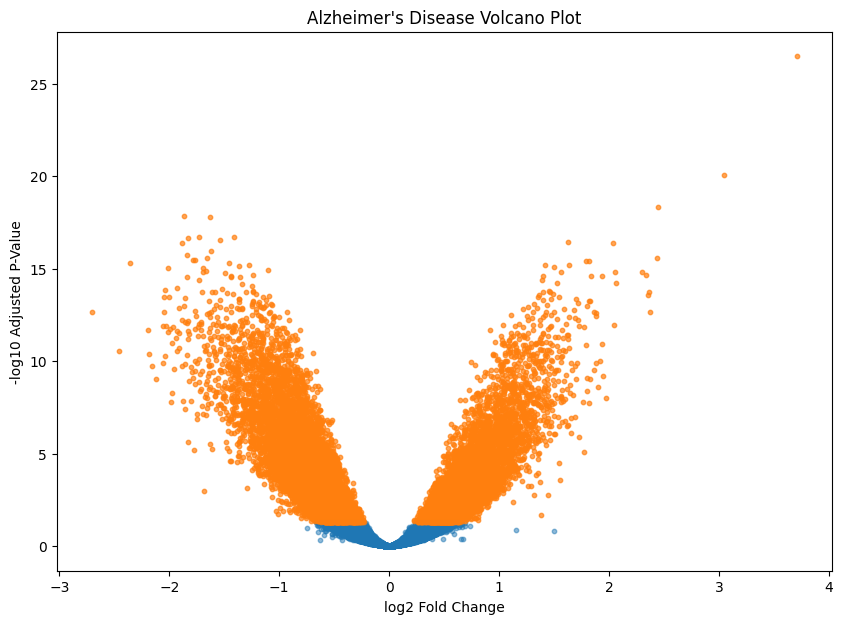

In [ ]:
plt.figure(figsize=(10, 7))

# Non-significant genes
plt.scatter(
    annotated_results[
        ~annotated_results["Significant"]
    ]["logFC"],

    annotated_results[
        ~annotated_results["Significant"]
    ]["neg_log10_p"],

    alpha=0.5,
    s=10
)

# Significant genes
plt.scatter(
    annotated_results[
        annotated_results["Significant"]
    ]["logFC"],

    annotated_results[
        annotated_results["Significant"]
    ]["neg_log10_p"],

    alpha=0.7,
    s=10
)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 Adjusted P-Value")
plt.title("Alzheimer's Disease Volcano Plot")

plt.show()

In [ ]:
top_genes = annotated_results.sort_values(
    by="adj.P.Val"
).head(10)

top_genes[[
    "Gene Symbol",
    "logFC",
    "adj.P.Val"
]]

,Gene Symbol,logFC,adj.P.Val
0,MIR612 /// NEAT1,3.707117,3.349426e-27
1,MIR612 /// NEAT1,3.044338,9.048050e-21
2,ITPKB,2.445461,4.534392e-19
3,ATP5C1,-1.863643,1.480209e-18
4,TUBB,-1.631276,1.655451e-18
6,PSMB3,-1.408793,2.022100e-17
5,TUBB4B,-1.726316,2.022100e-17
7,ATP5C1,-1.832512,2.227368e-17
10,TUBB,-1.537268,2.759185e-17
11,SLC35E1,1.627450,3.518514e-17


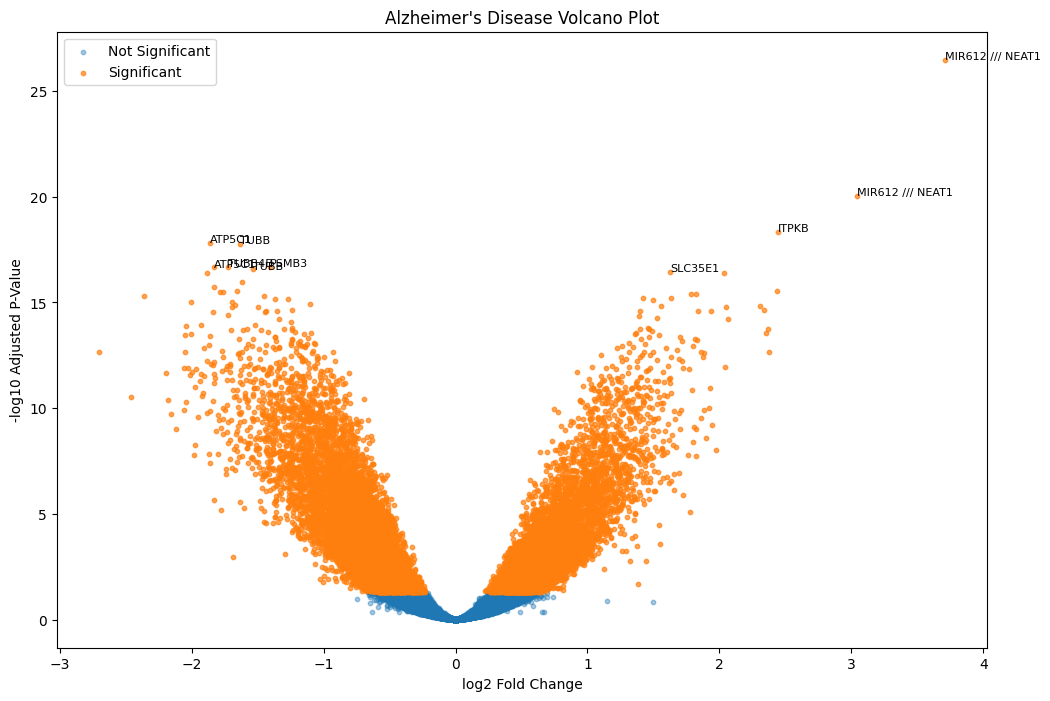

In [ ]:
plt.figure(figsize=(12, 8))

# Non-significant
nonsig = annotated_results[
    annotated_results["adj.P.Val"] >= 0.05
]

plt.scatter(
    nonsig["logFC"],
    nonsig["neg_log10_p"],
    alpha=0.4,
    s=10,
    label="Not Significant"
)

# Significant
sig = annotated_results[
    annotated_results["adj.P.Val"] < 0.05
]

plt.scatter(
    sig["logFC"],
    sig["neg_log10_p"],
    alpha=0.7,
    s=10,
    label="Significant"
)

# Label top genes
for _, row in top_genes.iterrows():

    plt.text(
        row["logFC"],
        row["neg_log10_p"],
        row["Gene Symbol"],
        fontsize=8
    )

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 Adjusted P-Value")
plt.title("Alzheimer's Disease Volcano Plot")

plt.legend()

plt.show()